In [1]:
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

In [2]:
def pad_image(img,border_width,border_color):
  if len(img.shape) == 2:
    h,w = img.shape
    new_h,new_w = h+2*border_width,w+2*border_width
    padded_img = np.full((new_h,new_w),border_color,dtype=img.dtype)
    padded_img[border_width:border_width+h,border_width:border_width+w] = img
  elif len(img.shape) == 3:
    h, w, c = img.shape
    new_h, new_w = h + 2 * border_width, w + 2 * border_width
    padded_img = np.zeros((new_h, new_w, c), dtype=img.dtype)
    for channel in range(c):
            padded_img[:, :, channel] = border_color[channel]
    padded_img[border_width:border_width + h, border_width:border_width + w, :] = img

  return padded_img

In [3]:
print("Upload an image:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Upload an image:


Saving RANDOM PIC.jpg to RANDOM PIC.jpg


In [4]:
bgr_img = cv2.imread(filename)
rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)

In [5]:
gray_img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
_, binary_img = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)

In [6]:
pad_width = int(input("Enter border width in pixels (e.g., 20): "))
gray_val = int(input("Enter border color intensity for Grayscale (0-255): "))
bin_val = int(input("Enter border color for Binary (0 or 255): "))

Enter border width in pixels (e.g., 20): 13
Enter border color intensity for Grayscale (0-255): 233
Enter border color for Binary (0 or 255): 123


In [7]:
print("\nEnter RGB border color values (0-255):")
r = int(input("Red:"))
g = int(input("Green:"))
b = int(input("Blue:"))


Enter RGB border color values (0-255):
Red:7
Green:12
Blue:22


In [8]:
padded_rgb = pad_image(rgb_img, pad_width, (r, g, b))
padded_gray = pad_image(gray_img, pad_width, gray_val)
padded_binary = pad_image(binary_img, pad_width, bin_val)

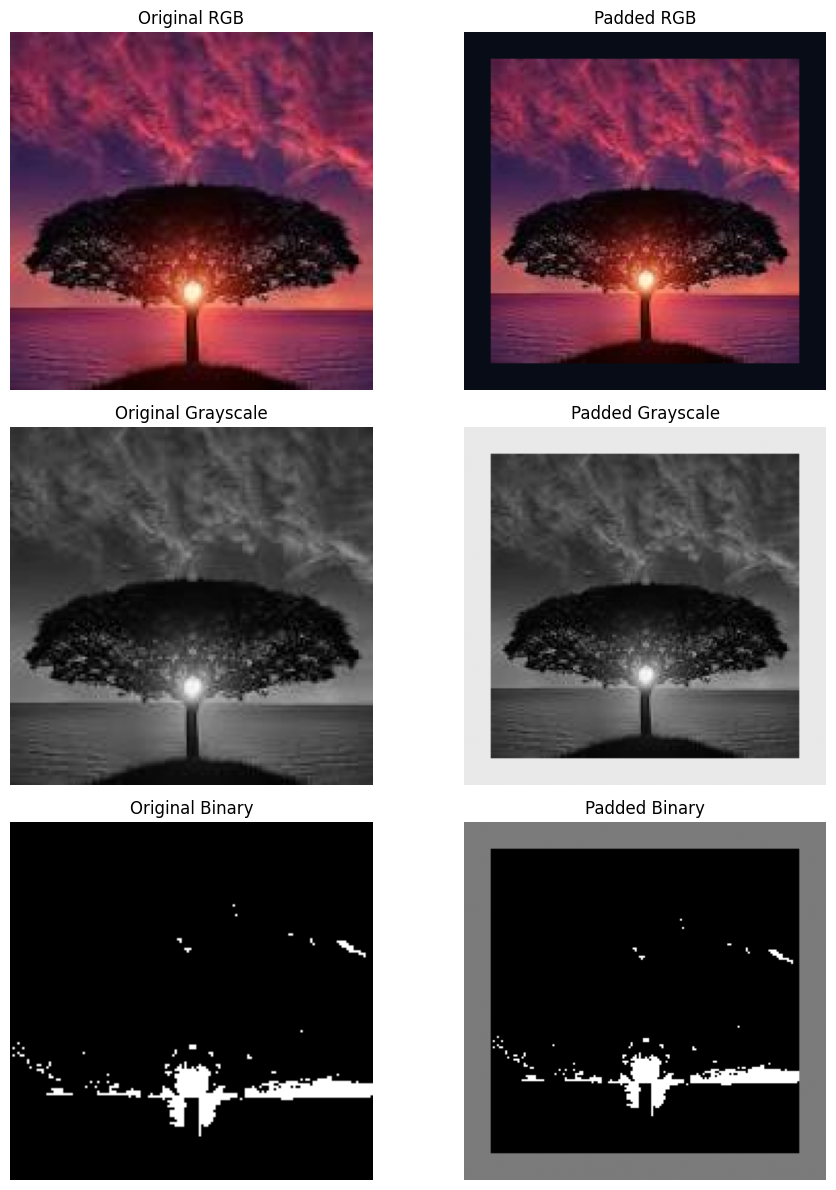

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

axes[0, 0].imshow(rgb_img)
axes[0, 0].set_title("Original RGB")
axes[0, 1].imshow(padded_rgb)
axes[0, 1].set_title("Padded RGB")

axes[1, 0].imshow(gray_img, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title("Original Grayscale")
axes[1, 1].imshow(padded_gray, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title("Padded Grayscale")

axes[2, 0].imshow(binary_img, cmap='gray', vmin=0, vmax=255)
axes[2, 0].set_title("Original Binary")
axes[2, 1].imshow(padded_binary, cmap='gray', vmin=0, vmax=255)
axes[2, 1].set_title("Padded Binary")

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

Upload an image:


Saving RANDOM PIC.jpg to RANDOM PIC (1).jpg


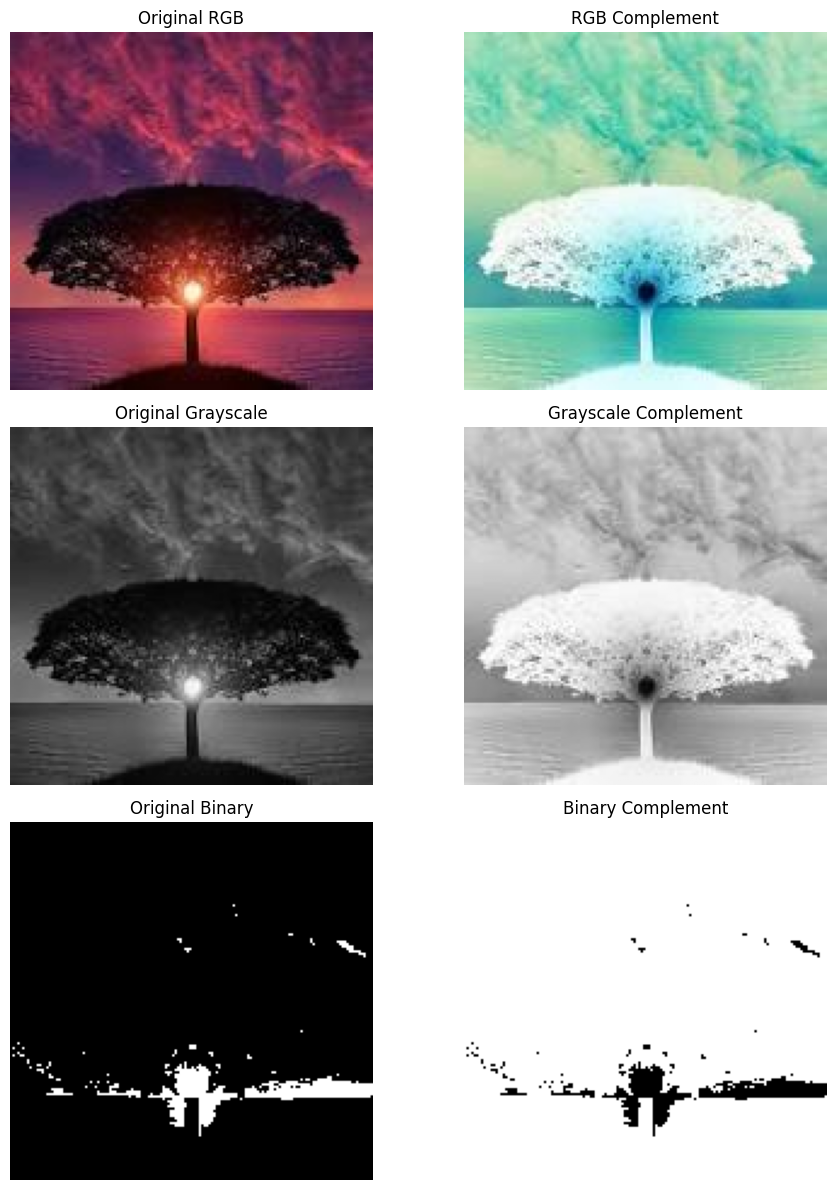

In [10]:
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

def complement_image(img, max_intensity=255):
    return max_intensity - img


print("Upload an image:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]


bgr_img = cv2.imread(filename)
rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)

gray_img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
_, binary_img = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)


comp_rgb = complement_image(rgb_img)
comp_gray = complement_image(gray_img)
comp_binary = complement_image(binary_img)


fig, axes = plt.subplots(3, 2, figsize=(10, 12))

axes[0, 0].imshow(rgb_img)
axes[0, 0].set_title("Original RGB")
axes[0, 1].imshow(comp_rgb)
axes[0, 1].set_title("RGB Complement")

axes[1, 0].imshow(gray_img, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title("Original Grayscale")
axes[1, 1].imshow(comp_gray, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title("Grayscale Complement")

axes[2, 0].imshow(binary_img, cmap='gray', vmin=0, vmax=255)
axes[2, 0].set_title("Original Binary")
axes[2, 1].imshow(comp_binary, cmap='gray', vmin=0, vmax=255)
axes[2, 1].set_title("Binary Complement")

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()